#Experiment: ROI analysis

The goal of this notebook is to train and evaluate the encoder-decoder pipeline using only subsets of voxels defined by anatomical ROIs (V1, V2, V3, V4, LOC, FFA, PPA, LVC, HVC). The dataset provides directly which voxels are in each part of the visual cortex.

Each experiment trains a new model on the ROI-masked fMRI data and evaluates using PixCorr, SSIM, CLIP similarity and 2-way accuracy.

The steps followed in this notebook are mostly the same as in the main notebook, only it focuses on the results aquired with part of the fMRI.

In [1]:
import os, random, json
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import requests
from tqdm import tqdm
from PIL import Image
from scipy.stats import pearsonr
from skimage.metrics import structural_similarity as ssim
import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from transformers import CLIPModel, CLIPProcessor
from google.colab import drive

In [2]:
drive.mount('/content/drive')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

Mounted at /content/drive
Device : cpu


In [3]:
project = '/content/image_reconstruction'
fMRI_dir = '/content/image_reconstruction/fMRI'
RESULTS_DIR = '/content/drive/MyDrive/results/'
MODELS_DIR = '/content/drive/MyDrive/models/'
ROI_DIR = '/content/drive/MyDrive/roi_experiment'

for d in [project, fMRI_dir, RESULTS_DIR, MODELS_DIR, ROI_DIR]:
    os.makedirs(d, exist_ok=True)

##1. Load data

In [4]:
MAT_URL = 'https://s3-eu-west-1.amazonaws.com/pfigshare-u-files/13663487/Subject1.mat'
MAT_PATH = os.path.join(fMRI_dir, 'Subject1.mat')

if os.path.exists(MAT_PATH):
    print('Subject1.mat already present')
else:
    print('Downloading Subject1.mat...')
    r = requests.get(MAT_URL, stream=True, headers={'User-Agent': 'Mozilla/5.0'})
    total = int(r.headers.get('content-length', 0))
    with open(MAT_PATH, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in r.iter_content(8192):
            f.write(chunk)
            bar.update(len(chunk))

100%|██████████| 120M/120M [00:10<00:00, 11.5MB/s]


In [5]:
with h5py.File(MAT_PATH, 'r') as f:
    data = f['dataSet'][:]
    meta = f['metaData/value'][:]
    key_refs = f['metaData/key'][:].flatten()
    keys = [''.join(chr(c[0]) for c in f[ref][:]) for ref in key_refs]

voxeldata_col = keys.index('VoxelData')
is_voxel = meta[:, voxeldata_col] == 1.0

fmri_all = data[is_voxel, :].T.astype(np.float32)
datatype = data[0, :].astype(int)
image_index = data[4470, :]

mask_train = datatype == 1
mask_test = datatype == 2

clip_val = 20.0
fmri_train = np.clip(fmri_all[mask_train], -clip_val, clip_val).astype(np.float32)
fmri_test_raw = np.clip(fmri_all[mask_test], -clip_val, clip_val).astype(np.float32)
img_idx_train = image_index[mask_train]
img_idx_test = image_index[mask_test]

unique_test_imgs = np.unique(img_idx_test[~np.isnan(img_idx_test)]).astype(int)
fmri_test = np.clip(np.array([fmri_test_raw[img_idx_test == img].mean(axis=0) for img in unique_test_imgs]), -clip_val, clip_val).astype(np.float32)

roi_names = ['ROI_V1','ROI_V2','ROI_V3','ROI_V4','ROI_LOC','ROI_FFA','ROI_PPA','ROI_LVC','ROI_HVC','ROI_VC']
roi_masks = {}
for roi in roi_names:
    if roi in keys:
        roi_masks[roi] = meta[is_voxel, keys.index(roi)] == 1.0

print(f'fmri_train : {fmri_train.shape}')
print(f'fmri_test : {fmri_test.shape}')
print('ROIs :')
for name, mask in roi_masks.items():
    print(f'  {name:10s} : {mask.sum()} voxels')

fmri_train : (1200, 4466)
fmri_test : (50, 4466)
ROIs :
  ROI_V1     : 1004 voxels
  ROI_V2     : 1018 voxels
  ROI_V3     : 759 voxels
  ROI_V4     : 740 voxels
  ROI_LOC    : 540 voxels
  ROI_FFA    : 568 voxels
  ROI_PPA    : 356 voxels
  ROI_LVC    : 2281 voxels
  ROI_HVC    : 2049 voxels
  ROI_VC     : 4466 voxels


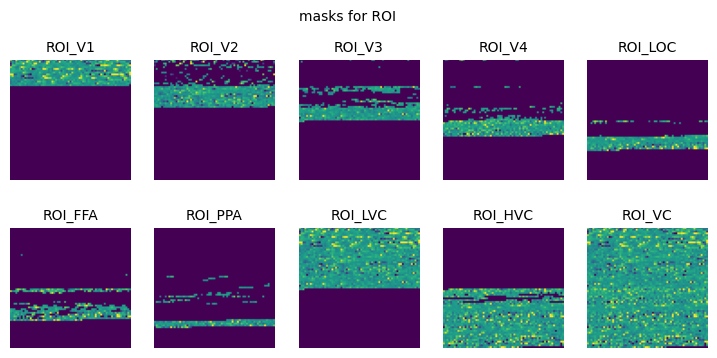

In [50]:
n = int(np.ceil(np.sqrt(len(fmri_train[0]))))
im = np.zeros(n*n)
im[:len(fmri_train[0])] = fmri_train[0]
im = im.reshape(n, n)
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
fig.suptitle('masks for ROI\n', fontsize=10)
i = 0
for name, mask in roi_masks.items():
  l = i//5
  c = i%5
  mask_ = np.zeros(n*n)
  mask_[:len(mask)] = mask
  mask_ = mask_.reshape(n, n)
  im_masked = im * mask_.reshape(n, n)
  blind = mask_ == 0
  im_masked[blind] = -10
  axes[l, c].imshow(im_masked, vmin=-10, vmax=10)
  axes[l, c].set_title(f'{name}', fontsize=10)
  axes[l, c].axis('off')
  i +=1

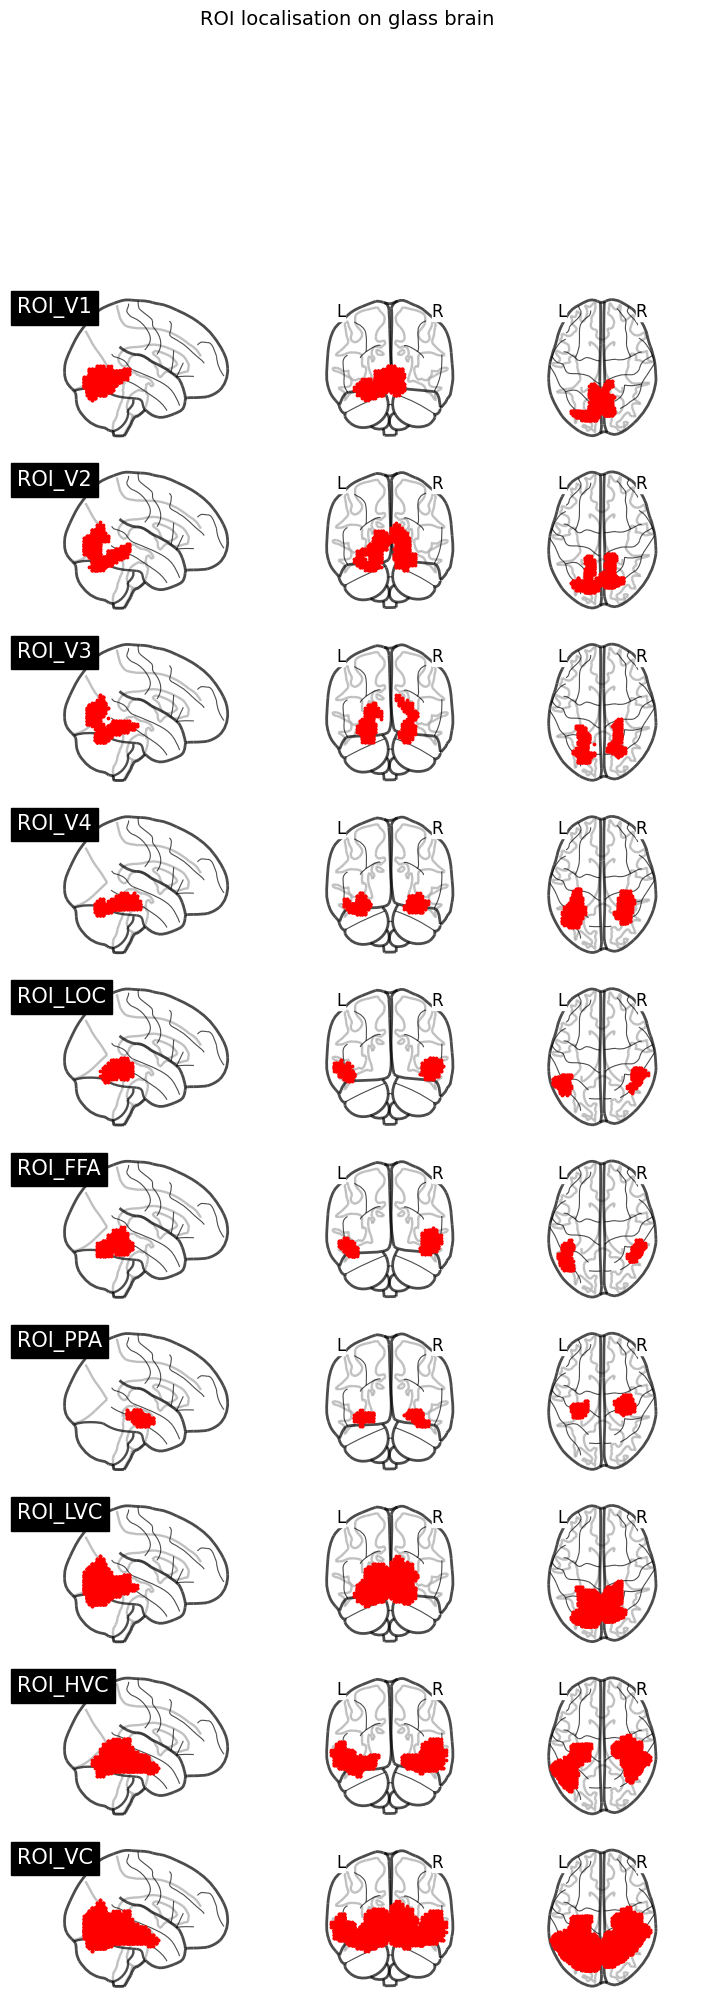

In [57]:
!pip install nilearn -q
from nilearn import plotting, image

x_coords = meta[is_voxel, keys.index('voxel_x')]
y_coords = meta[is_voxel, keys.index('voxel_y')]
z_coords = meta[is_voxel, keys.index('voxel_z')]

fig, axes = plt.subplots(len(roi_masks), 1, figsize=(9, 22))
fig.suptitle('ROI localisation on glass brain', fontsize=14, y=1.01)

for ax, (roi_name, mask) in zip(axes, roi_masks.items()):
    roi_x = x_coords[mask]
    roi_y = y_coords[mask]
    roi_z = z_coords[mask]
    coords = np.column_stack([roi_x, roi_y, roi_z])

    display = plotting.plot_connectome(
        np.zeros((len(coords), len(coords))),
        coords,
        node_size=3,
        node_color='red',
        display_mode='ortho',
        axes=ax,
        title=f'{roi_name}',
        colorbar=False,
    )
plt.show()

In [ ]:
import zipfile, getpass

ZIP_PATH = '/content/drive/MyDrive/images_passwd.zip'
EXTRACT_DIR = project
password = getpass.getpass('Zip password : ')

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR, pwd=password.encode('utf-8'))

test_dir = os.path.join(EXTRACT_DIR, 'images', 'test')
train_dir = os.path.join(EXTRACT_DIR, 'images', 'training')
test_id_csv = os.path.join(EXTRACT_DIR, 'images', 'image_test_id.csv')
train_id_csv = os.path.join(EXTRACT_DIR, 'images', 'image_training_id.csv')

ids_train = pd.read_csv(train_id_csv, header=None, names=['img_idx', 'filename'])
ids_test = pd.read_csv(test_id_csv, header=None, names=['img_idx', 'filename'])

train_idx_to_path = {i+1: os.path.join(train_dir, row['filename'].strip())
                     for i, row in ids_train.iterrows()
                     if os.path.exists(os.path.join(train_dir, row['filename'].strip()))}
test_idx_to_path  = {i+1: os.path.join(test_dir, row['filename'].strip())
                     for i, row in ids_test.iterrows()
                     if os.path.exists(os.path.join(test_dir, row['filename'].strip()))}

print(f'Train images : {len(train_idx_to_path)}/1200')
print(f'Test images : {len(test_idx_to_path)}/50')

Zip password : ··········
Train images : 1200/1200
Test images  : 50/50


In [ ]:
UNLABELED_DIR = '/content/image_reconstruction/unlabled'
os.makedirs(UNLABELED_DIR, exist_ok=True)

TINY_URL = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
TINY_ZIP = os.path.join(UNLABELED_DIR, 'tiny-imagenet-200.zip')
TINY_DIR = os.path.join(UNLABELED_DIR, 'tiny-imagenet-200')

if os.path.exists(TINY_DIR) and len(os.listdir(TINY_DIR)) > 0:
    print('TinyImageNet already there')
else:
    import requests
    r = requests.get(TINY_URL, stream=True)
    total = int(r.headers.get('content-length', 0))
    with open(TINY_ZIP, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in r.iter_content(8192):
            f.write(chunk)
            bar.update(len(chunk))
    with zipfile.ZipFile(TINY_ZIP, 'r') as z:
        z.extractall(UNLABELED_DIR)

unlabeled_paths = []
for root, dirs, files in os.walk(TINY_DIR):
    for fname in files:
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            unlabeled_paths.append(os.path.join(root, fname))

100%|██████████| 248M/248M [00:36<00:00, 6.75MB/s]


##2. Datasets, losses, metrics...

In [ ]:
IMG_SIZE = 112

transform_train = T.Compose([
    T.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    T.RandomCrop((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
transform_test = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


In [ ]:
class PairedDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, i):
        p = self.pairs[i]
        img = Image.open(p['img_path']).convert('RGB')
        return self.transform(img), torch.FloatTensor(p['fmri'])


class FMRIDataset(Dataset):
    def __init__(self, fmri_data):
        self.fmri = fmri_data
    def __len__(self):
        return len(self.fmri)
    def __getitem__(self, i):
        return torch.FloatTensor(self.fmri[i])

class UnlabeledImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths     = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        try:
            img = Image.open(self.paths[i]).convert('RGB')
            return self.transform(img)
        except Exception:
            return torch.zeros(3, IMG_SIZE, IMG_SIZE)


def build_pairs(fmri_data, img_indices, idx_to_path):
    pairs = []
    for trial_idx, img_pos in enumerate(img_indices):
        img_pos = int(img_pos)
        if img_pos in idx_to_path:
            pairs.append({'trial_idx': trial_idx, 'img_pos': img_pos,
                          'fmri': fmri_data[trial_idx], 'img_path': idx_to_path[img_pos]})
    return pairs

In [ ]:
alpha = 0.9

def fmri_loss(pred, target):
    mse = F.mse_loss(pred, target)
    cos = F.cosine_similarity(pred, target, dim=1).mean()
    return alpha * mse - (1 - alpha) * cos


class VGGFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        self.slice1 = vgg[:2]
        self.slice2 = vgg[:7]
        for p in self.parameters():
            p.requires_grad = False
    def forward(self, x):
        return self.slice1(x), self.slice2(x)

vgg_features = VGGFeatures().to(DEVICE)

def total_variation(img):
    return (torch.abs(img[:,:,1:,:] - img[:,:,:-1,:]).mean() +
            torch.abs(img[:,:,:,1:] - img[:,:,:,:-1]).mean())

def image_loss(recon, target):
    l_rgb = F.l1_loss(recon, target)
    f1, f2 = vgg_features(recon)
    g1, g2 = vgg_features(target)
    l_feat = F.mse_loss(f1, g1) + F.mse_loss(f2, g2)
    l_tv = total_variation(recon)
    return l_rgb + 0.1 * l_feat + 0.001 * l_tv

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 98.8MB/s]


In [ ]:
clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(DEVICE)
clip_proc = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model.eval()


def compute_reconstructions(decoder, dataset_test):
    decoder.eval()
    loader = DataLoader(dataset_test, batch_size=50, shuffle=False)
    imgs_gt, fmris_gt = next(iter(loader))
    with torch.no_grad():
        recons = decoder(fmris_gt.to(DEVICE)).cpu()
    imgs_01 = denormalize(imgs_gt)
    return recons, imgs_01


def compute_pixcorr(recons, imgs_01):
    scores = []
    for i in range(len(recons)):
        r, _ = pearsonr(imgs_01[i].numpy().flatten(), recons[i].numpy().flatten())
        scores.append(r)
    return float(np.mean(scores))


def compute_ssim(recons, imgs_01):
    scores = []
    for i in range(len(recons)):
        orig = imgs_01[i].permute(1,2,0).numpy()
        recon = recons[i].permute(1,2,0).numpy()
        scores.append(ssim(orig, recon, channel_axis=2, data_range=1.0))
    return float(np.mean(scores))


def compute_clip_similarity(recons, imgs_01):
    scores = []
    for i in range(len(recons)):
        orig_pil = Image.fromarray((imgs_01[i].permute(1,2,0).numpy()*255).astype(np.uint8))
        recon_pil = Image.fromarray((recons[i].permute(1,2,0).clamp(0,1).numpy()*255).astype(np.uint8))
        with torch.no_grad():
            f_o = clip_model.visual_projection(
                clip_model.vision_model(**clip_proc(images=orig_pil,  return_tensors='pt').to(DEVICE)).pooler_output)
            f_r = clip_model.visual_projection(
                clip_model.vision_model(**clip_proc(images=recon_pil, return_tensors='pt').to(DEVICE)).pooler_output)
            f_o = f_o / f_o.norm(dim=-1, keepdim=True)
            f_r = f_r / f_r.norm(dim=-1, keepdim=True)
            scores.append(F.cosine_similarity(f_o, f_r).item())
    return float(np.mean(scores))


def compute_nway(recons, imgs_01, n_way=2, n_trials=1000):
    n_test = len(recons)
    correct = 0
    for _ in range(n_trials):
        target_idx = random.randint(0, n_test - 1)
        distractors = random.sample([i for i in range(n_test) if i != target_idx], n_way - 1)
        candidates = [target_idx] + distractors
        random.shuffle(candidates)
        corrs = [pearsonr(recons[target_idx].numpy().flatten(),
                          imgs_01[c].numpy().flatten())[0] for c in candidates]
        if candidates[np.argmax(corrs)] == target_idx:
            correct += 1
    return correct / n_trials

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
def evaluate_all(decoder, dataset_test, save_path=None, title=None, name=None):
    recons, imgs_01 = compute_reconstructions(decoder, dataset_test)

    all_metrics = {
        'pixcorr': compute_pixcorr(recons, imgs_01),
        'ssim': compute_ssim(recons, imgs_01),
        'clip_sim': compute_clip_similarity(recons, imgs_01),
        '2way': compute_nway(recons, imgs_01, n_way=2,  n_trials=1000),
        '5way': compute_nway(recons, imgs_01, n_way=5,  n_trials=1000),
        '10way': compute_nway(recons, imgs_01, n_way=10, n_trials=1000),
    }

    if save_path is not None and name is not None:
        n = len(recons)
        n_cols = 10
        n_rows = (n // n_cols) * 2

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
        if title is not None:
            fig.suptitle(title, fontsize=12, y=1.01)
        for i in range(n):
            col = i % n_cols
            row_orig  = (i // n_cols) * 2
            row_recon = row_orig + 1
            axes[row_orig, col].imshow(imgs_01[i].permute(1, 2, 0))
            axes[row_orig, col].axis('off')
            axes[row_recon, col].imshow(recons[i].permute(1, 2, 0).clamp(0, 1))
            axes[row_recon, col].axis('off')
        for i in range(0, n_rows, 2):
            axes[i, 0].set_ylabel('Original', fontsize=8, rotation=90, labelpad=4)
            axes[i + 1, 0].set_ylabel('Reconstruction', fontsize=8, rotation=90, labelpad=4)
        plt.tight_layout()
        fig.savefig(os.path.join(save_path, f'reconstructions/reconstructions_{name}.png'), dpi=120, bbox_inches='tight')
        plt.close(fig)

        metric_names = ['pixcorr', 'ssim', 'clip_sim', '2way']
        metric_vals = [all_metrics[m] for m in metric_names]
        fig, ax = plt.subplots(figsize=(4, 4))
        bars = ax.bar(metric_names, metric_vals, color=['steelblue', 'darkorange', 'forestgreen', 'crimson'], width=0.7)
        for bar, val in zip(bars, metric_vals):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_ylabel('Score')
        ax.set_title(f'Metrics : {name}')
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        fig.savefig(os.path.join(save_path, f'other_metrics/metrics_{name}.png'), dpi=150, bbox_inches='tight')
        plt.close(fig)

    return all_metrics

##3. Encoder and Decoder

In [ ]:
def make_encoder(n_voxels):
    class Encoder(nn.Module):
        def __init__(self, n_voxels):
            super().__init__()
            alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
            self.alexnet_conv1 = alexnet.features[0]
            for p in self.alexnet_conv1.parameters():
                p.requires_grad = False
            self.bn_input = nn.BatchNorm2d(64)
            self.conv_blocks = nn.Sequential(
                nn.Conv2d(64, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU()
            )
            with torch.no_grad():
                dummy = torch.zeros(1, 3, 112, 112)
                dummy = self.alexnet_conv1(dummy)
                dummy = self.conv_blocks(dummy)
                flat_dim = dummy.view(1, -1).shape[1]
            self.fc = nn.Linear(flat_dim, n_voxels)
        def forward(self, x):
            with torch.no_grad():
                x = self.alexnet_conv1(x)
            x = self.bn_input(x)
            x = self.conv_blocks(x)
            x = x.view(x.size(0), -1)
            return self.fc(x)
    return Encoder(n_voxels).to(DEVICE)


def make_decoder(n_voxels):
    class Decoder(nn.Module):
        def __init__(self, n_voxels):
            super().__init__()
            self.fc = nn.Linear(n_voxels, 64 * 14 * 14)
            self.decoder_blocks = nn.Sequential(
                nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.BatchNorm2d(64),
                nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.BatchNorm2d(64),
                nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.BatchNorm2d(64),
            )
            self.output_conv = nn.Sequential(nn.Conv2d(64, 3, 3, padding=1), nn.Sigmoid())
        def forward(self, fmri):
            x = self.fc(fmri)
            x = x.view(-1, 64, 14, 14)
            x = self.decoder_blocks(x)
            return self.output_conv(x)
    return Decoder(n_voxels).to(DEVICE)


def train_encoder(encoder, dataset_train, n_epochs=80):
    loader = DataLoader(dataset_train, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    optimizer = torch.optim.SGD(encoder.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs + 20)
    losses = []
    for epoch in range(n_epochs):
        encoder.train()
        epoch_loss = 0
        for imgs, fmris in loader:
            imgs, fmris = imgs.to(DEVICE), fmris.to(DEVICE)
            optimizer.zero_grad()
            loss = fmri_loss(encoder(imgs), fmris)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        losses.append(epoch_loss / len(loader))
        if (epoch + 1) % 20 == 0:
            encoder.eval()
            with torch.no_grad():
                imgs_s, fmris_s = next(iter(DataLoader(dataset_train, batch_size=64, shuffle=False)))
                cos = F.cosine_similarity(encoder(imgs_s.to(DEVICE)).cpu(), fmris_s, dim=1).mean().item()
            encoder.train()
            print(f'    Enc epoch {epoch+1:3d}/{n_epochs}, loss={losses[-1]:.4f}, cos_sim={cos:.4f}')
    return losses


def train_decoder(encoder, decoder, dataset_train, dataset_fmri_test, dataset_unlabeled, n_epochs=120):
    encoder.eval()
    for p in encoder.parameters():
        p.requires_grad = False
    loader_sup = DataLoader(dataset_train, batch_size=36, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    loader_fmri = DataLoader(dataset_fmri_test, batch_size=12, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    loader_unlab = DataLoader(dataset_unlabeled, batch_size=12, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.2)
    mean_t = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(DEVICE)
    std_t = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(DEVICE)
    def infinite_loader(loader):
        while True:
            for batch in loader:
                yield batch
    iter_fmri = infinite_loader(loader_fmri)
    iter_unlab = infinite_loader(loader_unlab)
    losses = {'total': [], 'L_D': [], 'L_ED': [], 'L_DE': []}

    for epoch in range(n_epochs):
        decoder.train()
        ep_total, ep_ld, ep_led, ep_lde, n_steps = 0, 0, 0, 0, 0
        for imgs_sup, fmris_sup in loader_sup:
            imgs_sup, fmris_sup = imgs_sup.to(DEVICE), fmris_sup.to(DEVICE)
            fmris_test_b = next(iter_fmri).to(DEVICE)
            imgs_unlab = next(iter_unlab).to(DEVICE)
            optimizer.zero_grad()
            imgs_sup_01 = (imgs_sup * std_t + mean_t).clamp(0, 1)
            imgs_unlab_01 = (imgs_unlab * std_t + mean_t).clamp(0, 1)
            l_d = image_loss(decoder(fmris_sup), imgs_sup_01)
            with torch.no_grad():
                fmri_unlab = encoder(imgs_unlab)
            l_ed = image_loss(decoder(fmri_unlab), imgs_unlab_01)
            recon_fmri = decoder(fmris_test_b)
            l_de = fmri_loss(encoder(recon_fmri), fmris_test_b)
            total = l_d + l_ed + 0.05 * l_de
            total.backward()
            nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
            optimizer.step()
            ep_total += total.item()
            ep_ld += l_d.item()
            ep_led += l_ed.item()
            ep_lde += l_de.item()
            n_steps += 1
        scheduler.step()
        losses['total'].append(ep_total / n_steps)
        losses['L_D'].append(ep_ld / n_steps)
        losses['L_ED'].append(ep_led / n_steps)
        losses['L_DE'].append(ep_lde / n_steps)
        if (epoch + 1) % 30 == 0:
            print(f'    Dec epoch {epoch+1:3d}/{n_epochs}, total={losses["total"][-1]:.4f}, 'f'L_D={losses["L_D"][-1]:.4f}, L_ED={losses["L_ED"][-1]:.4f}')
    return losses

##4. ROI comparison

In [ ]:
ROI_EXPERIMENTS = {
    'full_VC' : None,
    #'ROI_V1' : roi_masks.get('ROI_V1'),
    #'ROI_V2' : roi_masks.get('ROI_V2'),
    #'ROI_V3' : roi_masks.get('ROI_V3'),
    #'ROI_V4' : roi_masks.get('ROI_V4'),
    'ROI_LOC' : roi_masks.get('ROI_LOC'),
    'ROI_FFA' : roi_masks.get('ROI_FFA'),
    'ROI_PPA' : roi_masks.get('ROI_PPA'),
    'ROI_LVC' : roi_masks.get('ROI_LVC'),
    'ROI_HVC' : roi_masks.get('ROI_HVC'),
}

N_EPOCHS_ENC = 80
N_EPOCHS_DEC = 120

all_results = {}

for roi_name, mask in ROI_EXPERIMENTS.items():
    print(f'\n{'='*50}')
    print(f'Experiment : {roi_name}')

    fmri_tr = fmri_train[:, mask] if mask is not None else fmri_train
    fmri_te = fmri_test[:, mask] if mask is not None else fmri_test
    n_vox = int(fmri_tr.shape[1])
    print(f'  Voxels : {n_vox}')

    pairs_tr = build_pairs(fmri_tr, img_idx_train, train_idx_to_path)
    pairs_te = [{'fmri': fmri_te[i], 'img_path': test_idx_to_path[img_pos]}
                for i, img_pos in enumerate(unique_test_imgs)
                if img_pos in test_idx_to_path]

    dataset_train_roi = PairedDataset(pairs_tr, transform_train)
    dataset_test_roi = PairedDataset(pairs_te, transform_test)
    dataset_fmri_roi = FMRIDataset(fmri_te)
    dataset_unlabeled_roi = UnlabeledImageDataset(unlabeled_paths, transform_train)

    encoder = make_encoder(n_vox)
    decoder = make_decoder(n_vox)

    print('  Training encoder...')
    enc_losses = train_encoder(encoder, dataset_train_roi, n_epochs=N_EPOCHS_ENC)

    print('  Training decoder...')
    dec_losses = train_decoder(encoder, decoder, dataset_train_roi, dataset_fmri_roi, dataset_unlabeled_roi, n_epochs=N_EPOCHS_DEC)

    torch.save(encoder.state_dict(), os.path.join(MODELS_DIR, f'encoders/encoder_{roi_name}.pt'))
    torch.save(decoder.state_dict(), os.path.join(MODELS_DIR, f'decoders/decoder_{roi_name}.pt'))

    print('  Evaluating...')
    metrics = evaluate_all(
        decoder, dataset_test_roi,
        save_path=RESULTS_DIR,
        title=f'Reconstructions : {roi_name} ({n_vox} voxels)',
        name=roi_name
    )
    metrics['n_voxels'] = n_vox
    metrics['enc_losses'] = enc_losses
    metrics['dec_losses'] = dec_losses
    all_results[roi_name] = metrics

    with open(os.path.join(RESULTS_DIR, 'roi_results.json'), 'w') as f:
        json.dump({k: {m: v for m, v in res.items() if m not in ['enc_losses', 'dec_losses']} for k, res in all_results.items()}, f, indent=2)
    print(f'  pixcorr={metrics["pixcorr"]:.3f}, ssim={metrics["ssim"]:.3f}, 'f'clip={metrics["clip_sim"]:.3f}, 2-way={metrics["2way"]*100:.1f}%')

print('\nAll experiments done. Results saved.')


Experiment : full_VC
  Voxels : 4466
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 174MB/s]


  Training encoder...
    Enc epoch  20/80, loss=12.2760, cos_sim=0.2158
    Enc epoch  40/80, loss=10.6515, cos_sim=0.4501
    Enc epoch  60/80, loss=9.2634, cos_sim=0.5197
    Enc epoch  80/80, loss=8.4560, cos_sim=0.5870
  Training decoder...
    Dec epoch  30/120 | total=0.4679 | L_D=0.2344 | L_ED=0.1699
    Dec epoch  60/120 | total=0.4066 | L_D=0.1899 | L_ED=0.1493
    Dec epoch  90/120 | total=0.3814 | L_D=0.1696 | L_ED=0.1442
    Dec epoch 120/120 | total=0.3731 | L_D=0.1646 | L_ED=0.1391
  Evaluating...
  pixcorr=0.273, ssim=0.248, clip=0.541, 2-way=71.8%

Experiment : ROI_LOC
  Voxels : 540
  Training encoder...
    Enc epoch  20/80, loss=9.0669, cos_sim=0.4564
    Enc epoch  40/80, loss=7.4404, cos_sim=0.6267
    Enc epoch  60/80, loss=6.4776, cos_sim=0.6368
    Enc epoch  80/80, loss=5.9062, cos_sim=0.7125
  Training decoder...
    Dec epoch  30/120 | total=0.6188 | L_D=0.2629 | L_ED=0.2160
    Dec epoch  60/120 | total=0.5598 | L_D=0.2272 | L_ED=0.1906
    Dec epoch  90/12

##5. Results visualization

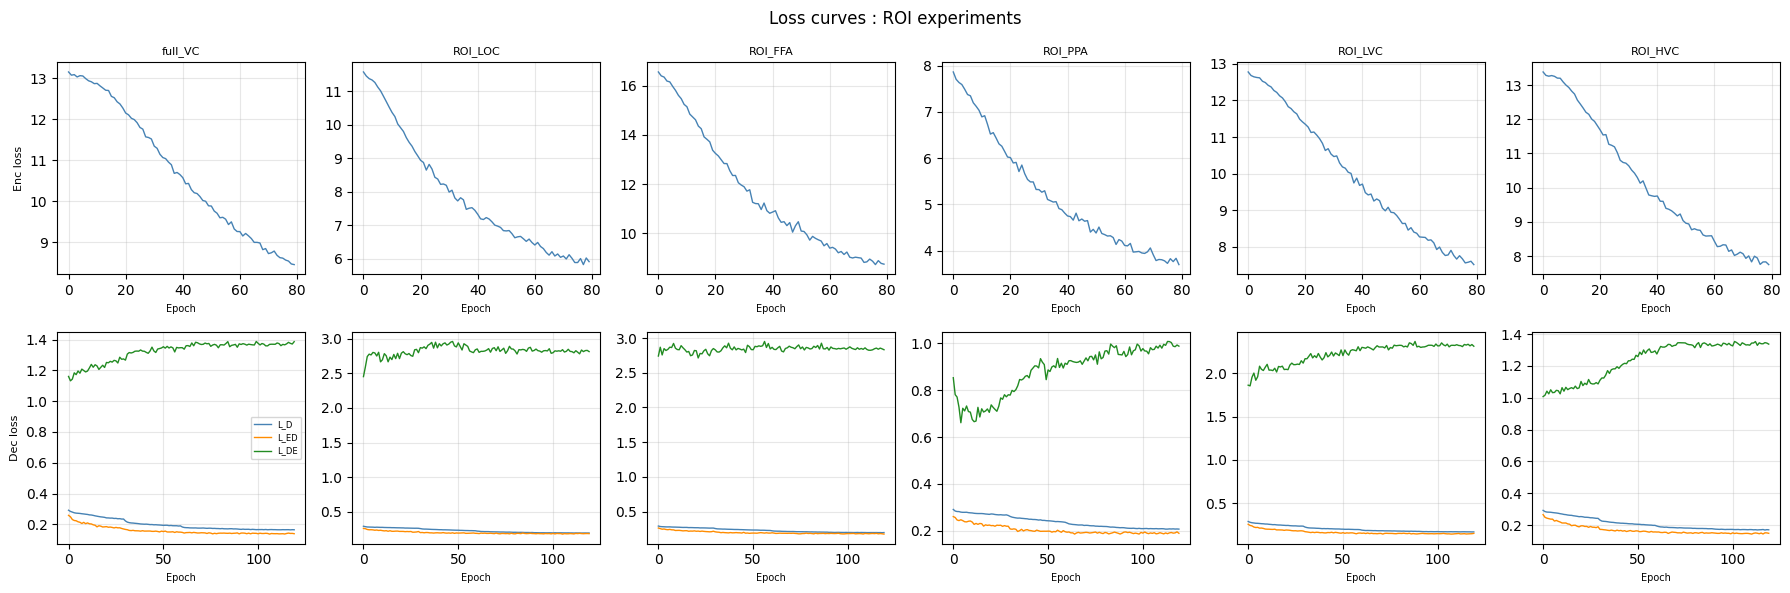

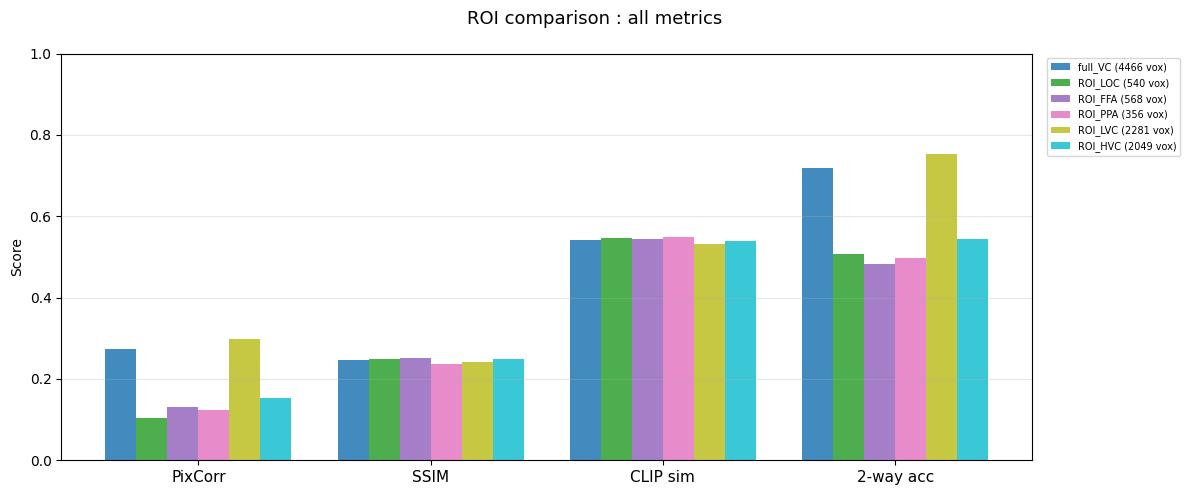

In [ ]:
# Loss curves
fig, axes = plt.subplots(2, len(all_results), figsize=(len(all_results)*3, 6))
fig.suptitle('Loss curves : ROI experiments', fontsize=12)

for col, (roi_name, res) in enumerate(all_results.items()):
    axes[0, col].plot(res['enc_losses'], color='steelblue', lw=1)
    axes[0, col].set_title(roi_name, fontsize=8)
    axes[0, col].set_xlabel('Epoch', fontsize=7)
    if col == 0:
        axes[0, col].set_ylabel('Enc loss', fontsize=8)
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].plot(res['dec_losses']['L_D'],  color='steelblue',  lw=1, label='L_D')
    axes[1, col].plot(res['dec_losses']['L_ED'], color='darkorange',  lw=1, label='L_ED')
    axes[1, col].plot(res['dec_losses']['L_DE'], color='forestgreen', lw=1, label='L_DE')
    axes[1, col].set_xlabel('Epoch', fontsize=7)
    if col == 0:
        axes[1, col].set_ylabel('Dec loss', fontsize=8)
        axes[1, col].legend(fontsize=6)
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#hist of the metrics for each roi
metric_names = ['pixcorr', 'ssim', 'clip_sim', '2way']
metric_labels = ['PixCorr', 'SSIM', 'CLIP sim', '2-way acc']
roi_names_list = list(all_results.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(roi_names_list)))

x = np.arange(len(metric_names))
width = 0.8 / len(roi_names_list)

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('ROI comparison : all metrics', fontsize=13)

for i, (roi_name, color) in enumerate(zip(roi_names_list, colors)):
    vals = [all_results[roi_name][m] for m in metric_names]
    offset = (i - len(roi_names_list) / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=f'{roi_name} ({all_results[roi_name]["n_voxels"]} vox)', color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'roi_experiment/roi_combined_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()